# High-Dimensional Parameter Emulation

SMLR handles arbitrary parameter dimensions. This tutorial demonstrates
emulation with 4 input parameters controlling a complex spectrum.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from smlr import Surrogate, StrengthDataset, StrengthSample
from smlr.metrics import normalized_l2

## Generate 4D Parameter Space Data

We create spectra where each of 4 parameters affects different aspects.

In [2]:
def complex_spectrum(params, energy):
    """4-parameter spectrum model.
    
    params[0]: controls low-energy peak position
    params[1]: controls high-energy peak position  
    params[2]: controls relative amplitudes
    params[3]: controls global width scaling
    """
    p1, p2, p3, p4 = params
    
    e1 = 5 + 3 * p1
    e2 = 15 + 5 * p2
    a1 = 0.5 + 0.5 * p3
    a2 = 1.0 - 0.3 * p3
    gamma = 1.0 + 0.5 * p4
    
    def lorentz(e, e0, g, a):
        return a * g / np.pi / ((e - e0)**2 + g**2)
    
    return lorentz(energy, e1, gamma, a1) + lorentz(energy, e2, gamma, a2)

# Latin hypercube-like sampling in 4D
rng = np.random.default_rng(42)
n_samples = 50
param_samples = rng.uniform(0, 1, size=(n_samples, 4))

energy = np.linspace(0, 30, 200)
samples = []
for params in param_samples:
    spectrum = complex_spectrum(params, energy)
    samples.append(StrengthSample(params, energy, spectrum))

dataset = StrengthDataset(samples)
print(f"Created {len(samples)} samples in 4D parameter space")

Created 50 samples in 4D parameter space


## Train and Evaluate

In [3]:
# Use polynomial regression for higher dimensions
# model = Surrogate(
#     'regression',
#     n_components=3,
#     width_mode='global',
#     regression_method='polynomial',
#     poly_degree=2,
#     random_state=42
# )
model = Surrogate(
    'pmm',
    n_poles=7
)
model.fit(dataset)

# Test at random points
n_test = 10
test_params = rng.uniform(0, 1, size=(n_test, 4))

errors = []
for params in test_params:
    result = model.predict(params, energy)
    truth = complex_spectrum(params, energy)
    errors.append(normalized_l2(result.spectrum, truth, energy))

print(f"Mean error over {n_test} test points: {np.mean(errors):.4f}")
print(f"Max error: {np.max(errors):.4f}")

Mean error over 10 test points: 0.0078
Max error: 0.0128


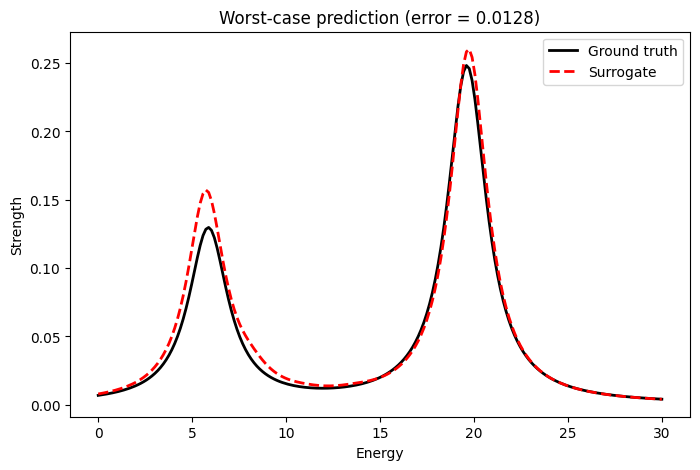

In [4]:
# Visualize worst case
worst_idx = np.argmax(errors)
worst_params = test_params[worst_idx]
result = model.predict(worst_params, energy)
truth = complex_spectrum(worst_params, energy)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(energy, truth, 'k-', lw=2, label='Ground truth')
ax.plot(energy, result.spectrum, 'r--', lw=2, label='Surrogate')
ax.set_xlabel('Energy')
ax.set_ylabel('Strength')
ax.set_title(f'Worst-case prediction (error = {errors[worst_idx]:.4f})')
ax.legend()
fig